In [18]:
import torch as trc
import os 
import numpy as np
import modelArch
import matplotlib.pyplot as plt

In [2]:
optical_path =r"D:\Resume Projs\All-Weather-Land-Cover-Intelligence-using-SAR-Optical-Fusion\data\dataset\optical"

In [13]:
allfiles = sorted([f[4:] for f in os.listdir(optical_path)])
cols = 29
rows = 55
fullPred = np.zeros((rows*128 , cols*128) , dtype = np.uint8)
fullLabel  = np.zeros( (rows*128 , cols*128) , dtype= np.int8)
fullRGB = np.zeros( (rows*128, cols*128,3) , dtype = np.float32)
sar_path = r"D:\Resume Projs\All-Weather-Land-Cover-Intelligence-using-SAR-Optical-Fusion\data\dataset\sar"
opt_path = r"D:\Resume Projs\All-Weather-Land-Cover-Intelligence-using-SAR-Optical-Fusion\data\dataset\optical"
lbl_path = r"D:\Resume Projs\All-Weather-Land-Cover-Intelligence-using-SAR-Optical-Fusion\data\dataset\labels"


In [10]:
model = modelArch.UNet()
model.load_state_dict((trc.load("best_model.pth"))['model_state_dict'])


<All keys matched successfully>

In [11]:
device = trc.device("cuda" if trc.cuda.is_available() else "cpu")
print(device)

cuda


In [14]:
model.to(device)
model.eval()

with trc.no_grad():
    for tiles,filename in enumerate(allfiles):
        row = tiles // cols
        col = tiles % cols
        r, c = row * 128, col * 128
        sarfile = os.path.join(sar_path,"sar_"+filename)
        optfile = os.path.join(opt_path, "opt_"+filename)
        labels = os.path.join(lbl_path, "lbl_"+ filename)

        sar = np.load(sarfile)
        opt = np.load(optfile)
        label= np.load(labels)

        fused = np.concatenate([sar,opt], axis=0)
        fused = trc.tensor(fused, dtype=trc.float32).unsqueeze(0).to(device)
        outputs = model(fused)
        pred = trc.argmax(outputs, dim =1)

        fullPred[r:r+128, c:c+128] = pred.squeeze(0).cpu().numpy()
        fullLabel[r:r+128, c:c+128] = label
        fullRGB[r:r+128, c:c+128] = opt[[2,1,0]].transpose(1,2,0)


In [15]:
def colorize(mask):
    colors = {
        0: [0, 0, 0],
        1: [0, 128, 0],
        2: [255, 0, 0],
        3: [139, 69, 19],
        4: [0, 0, 255]
    }
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in colors.items():
        color_mask[mask == cls] = color
    return color_mask

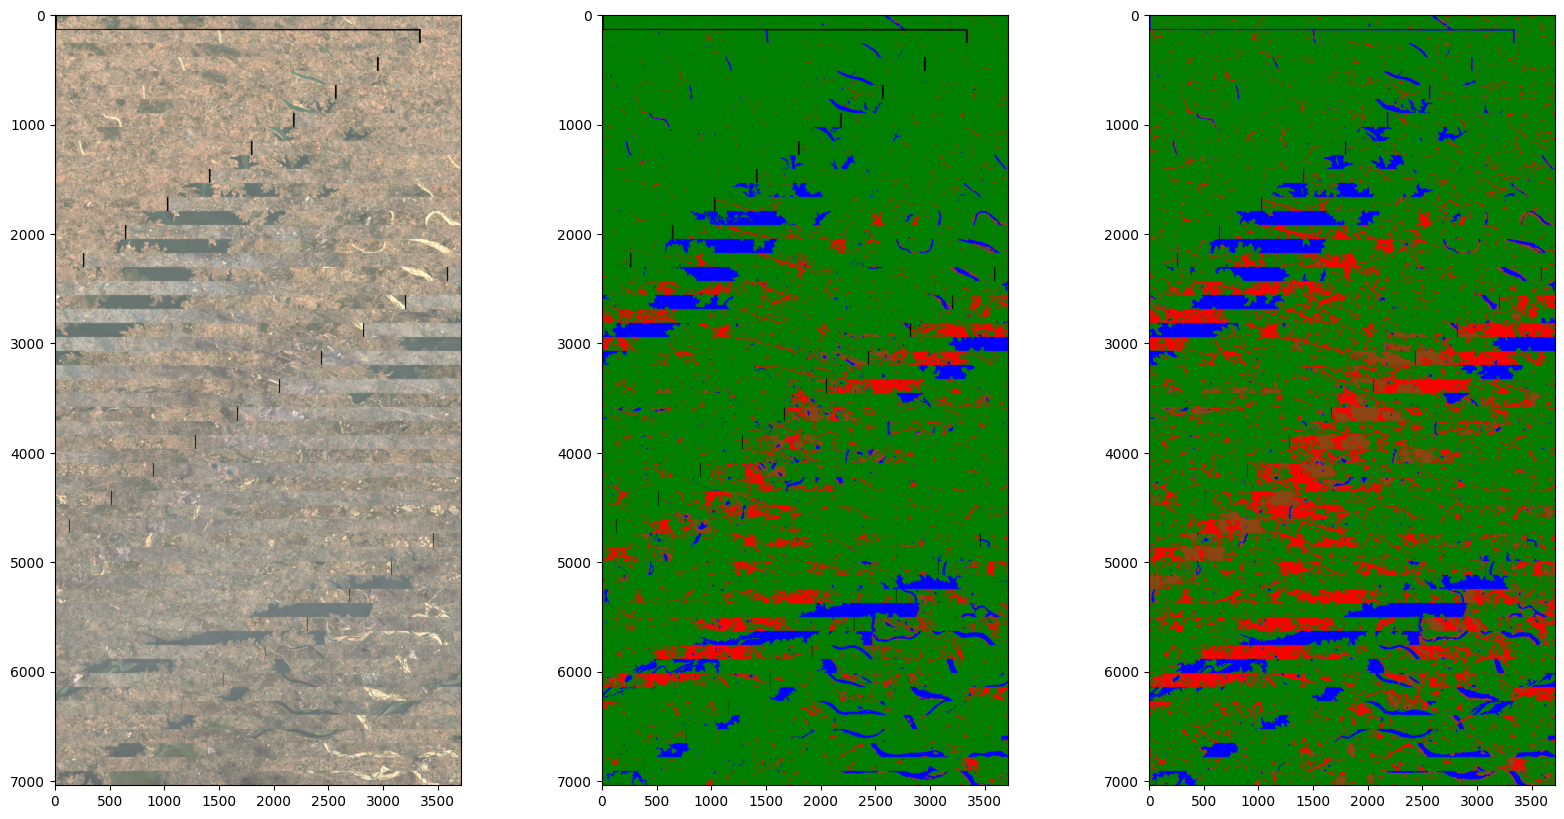

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
rgb = np.clip(fullRGB * 3.5, 0, 1)
axes[0].imshow(rgb)
axes[1].imshow(colorize(fullLabel))
axes[2].imshow(colorize(fullPred))